In [2]:
#PCA vs t-SNE for Visualizing Word Embeddings

# PCA → preserves overall variance
# t-SNE → preserves neighborhood relationships
# PCA is faster and better for large datasets, while t-SNE can capture more complex structures but is computationally intensive.

In [3]:
import gensim.downloader as api
import numpy as np

glove = api.load("glove-wiki-gigaword-100")

In [4]:
words = [
    "king", "queen", "prince", "princess",
    "doctor", "hospital", "nurse", "patient",
    "football", "soccer", "basketball", "tennis"
]

In [5]:
# Get the vectors for the selected words
vectors = np.array([
    glove[word]
    for word in words
])
print(vectors.shape)

(12, 100)


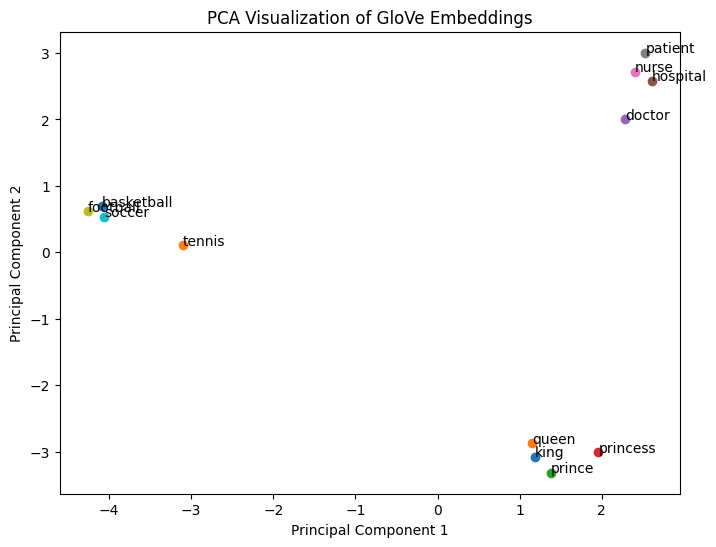

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce from 100 dimensions to 2
pca = PCA(n_components=2)

##fit_transform() → computes the PCA and applies the dimensionality reduction to the data, returning the transformed data in the new 2D space.
#fit: PCA studies the data.
# transform(): Projects all vectors onto those directions.

points_pca = pca.fit_transform(vectors)

# Plot
plt.figure(figsize=(8,6))

for i, word in enumerate(words): #loop through each word and its corresponding PCA point

    plt.scatter(
        points_pca[i,0], # X-coordinate of the PCA point
        points_pca[i,1]  # Y-coordinate of the PCA point
    )

    # Annotate the point with the word label
    plt.annotate(
        word,
        (points_pca[i,0], points_pca[i,1])
    )

plt.title("PCA Visualization of GloVe Embeddings")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

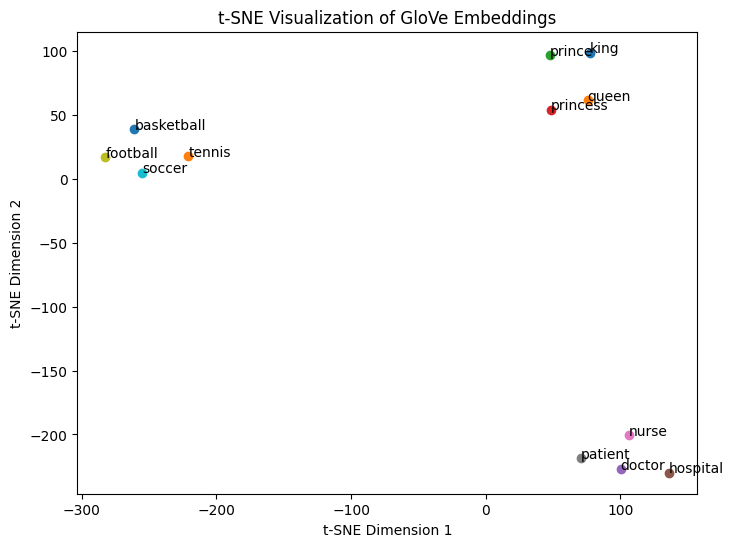

In [9]:

from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2, # Reduce to 2 dimensions for visualization
    perplexity=3, # Controls the balance between neighborhood size
    random_state=42 # Ensures reproducible results
)

points = tsne.fit_transform(vectors)
plt.figure(figsize=(8,6))
for i, word in enumerate(words):

    plt.scatter(
        points[i,0], # X-coordinate of the t-SNE point
        points[i,1] # Y-coordinate of the t-SNE point
    )

# Annotate the point with the word label   
    plt.annotate(
        word,
        (points[i,0], points[i,1])
    )

plt.title("t-SNE Visualization of GloVe Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()